In [1]:
# #  Car Price Prediction

# Ever wondered what your car is actually worth? This project builds a machine learning model to predict car selling prices based on various features like the car's age, mileage, fuel type, and more.

# # New concepts you now own:

# * Regression vs classification — predicting numbers not categories
# * Feature engineering — converting Year → Car_Age
# * One-hot encoding — converting text categories to binary columns
# * Log transformation — fixing skewed target distributions
# * expm1 — reversing log transformation on predictions
# * MAE, RMSE, R² — regression evaluation metrics
# * Actual vs Predicted plot — visual regression evaluation
# * Feature importance — understanding what the model actually learned
# * Random Forest — ensemble learning, why it beats a single tree
# * Multicollinearity — seeing it in the dummy variable columns

# ## What This Does

# Given information about a car (how old it is, how many kilometers it has driven, its current market price, etc.), this model predicts what price it would sell for. Super useful for:
# - Car dealerships pricing their inventory
# - Individuals selling their used cars
# - Anyone curious about car valuations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Datasets/car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print(df.shape)
print('--')
df.info()

(301, 9)
--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [6]:
# Convert Year to Age (more meaningful than raw year)
df['Car_Age'] = 2026 - df['Year']

# Drop columns we don't need for modeling
df = df.drop(['Car_Name', 'Year'], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [7]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], 
                    drop_first=True)
df.head()


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


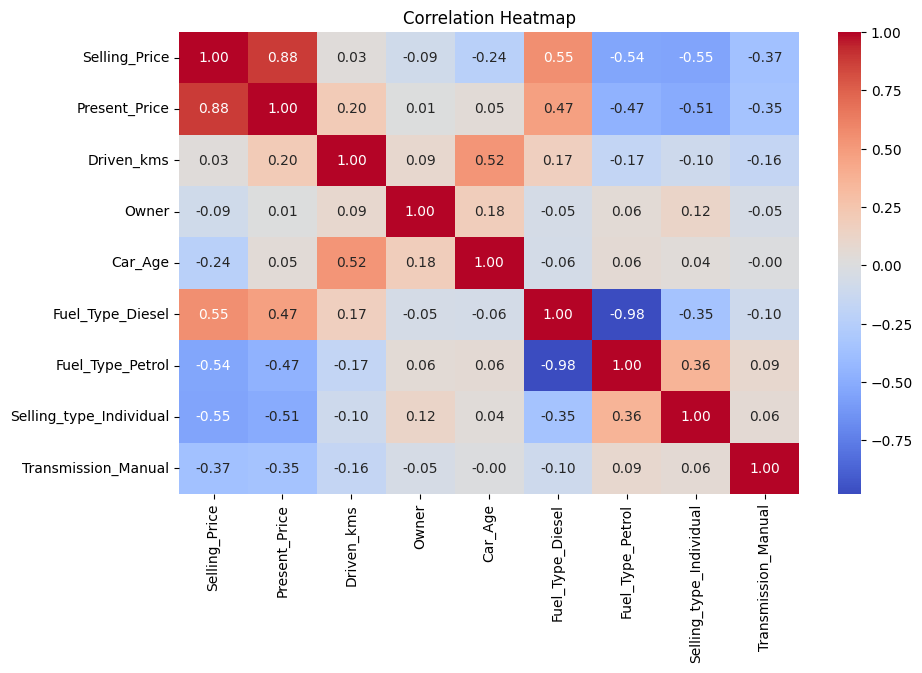

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

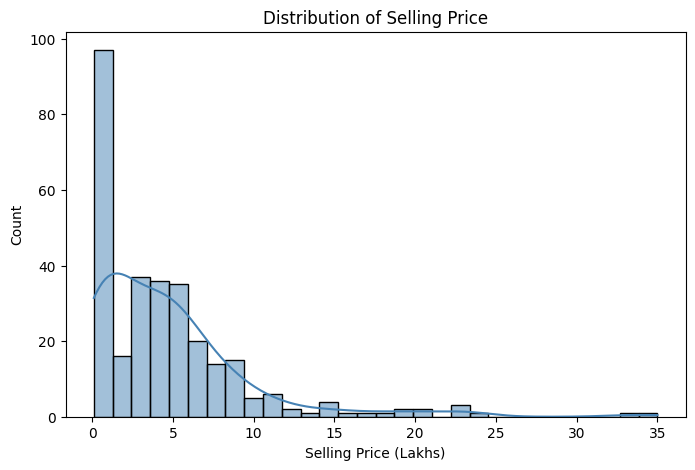

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.show()

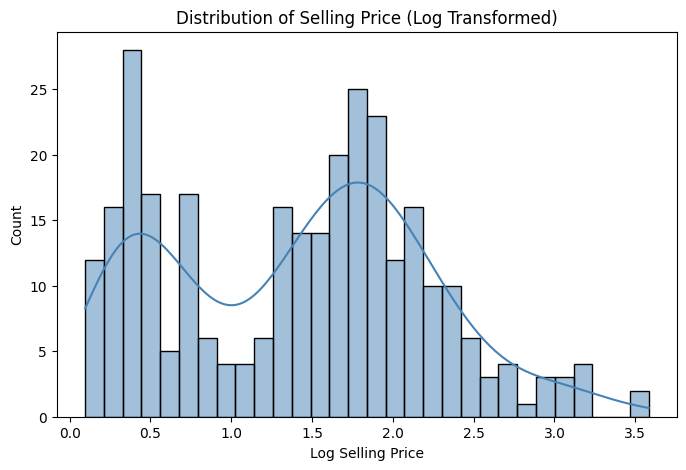

In [10]:
df['Selling_Price_log'] = np.log1p(df['Selling_Price'])

plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price_log'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Selling Price (Log Transformed)')
plt.xlabel('Log Selling Price')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(['Selling_Price', 'Selling_Price_log'], axis=1)
y = df['Selling_Price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features: {X.columns.tolist()}")

Training samples: 240
Testing samples: 61
Features: ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")

Model trained successfully!
Number of trees: 100


In [13]:
y_pred_log = model.predict(X_test)

# Convert predictions back from log space to actual lakhs
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"MAE: {mae: .2f} lakhs")
print(f"RMSE: {rmse: .2f} lakhs")
print(f"R²:   {r2:.3f}")

MAE:  0.63 lakhs
RMSE:  1.01 lakhs
R²:   0.956


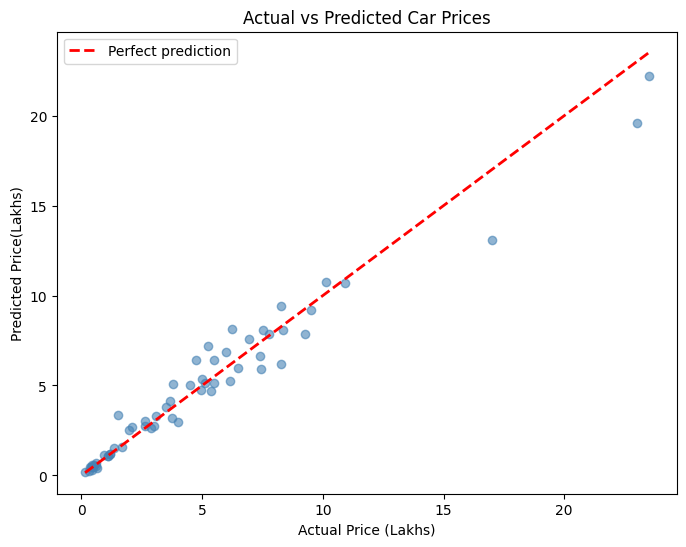

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price(Lakhs)')
plt.title('Actual vs Predicted Car Prices')
plt.legend()
plt.show()


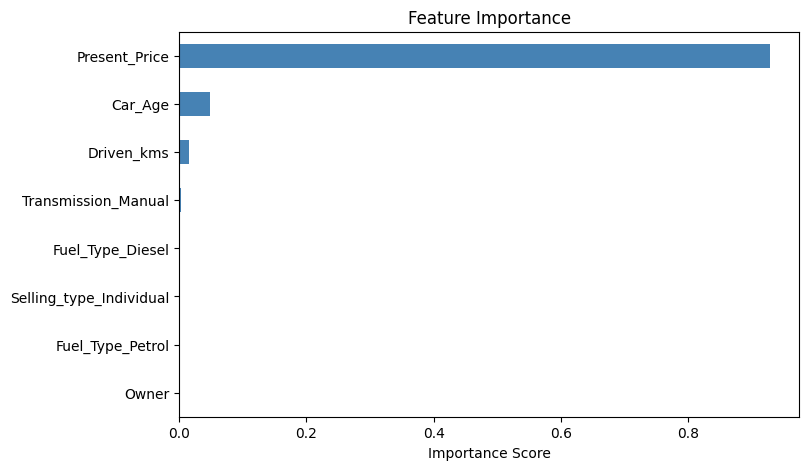

In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()